## 산점도

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')

In [6]:
data.head()

,year,city_code,gender,age_code,height,weight,waist,eye_left,eye_right,hear_left,...,serum,AST,ALT,GTP,smoking,drinking,oral_check,dental_caries,tartar,open_date
0,2020,36,1,9,165,60,72.1,1.2,1.5,1,...,1.1,21.0,27.0,21.0,1,0,0,NaN,NaN,2021-12-29
1,2020,27,2,13,150,65,81.0,0.8,0.8,1,...,0.5,18.0,15.0,15.0,1,0,0,NaN,NaN,2021-12-29
2,2020,11,2,12,155,55,70.0,0.6,0.7,1,...,0.7,27.0,25.0,7.0,1,0,0,NaN,NaN,2021-12-29
3,2020,31,1,13,160,70,90.8,1.0,1.0,1,...,1.2,65.0,97.0,72.0,1,0,1,0.0,0.0,2021-12-29
4,2020,41,2,12,155,50,75.2,1.5,1.2,1,...,0.7,18.0,17.0,14.0,1,0,0,NaN,NaN,2021-12-29


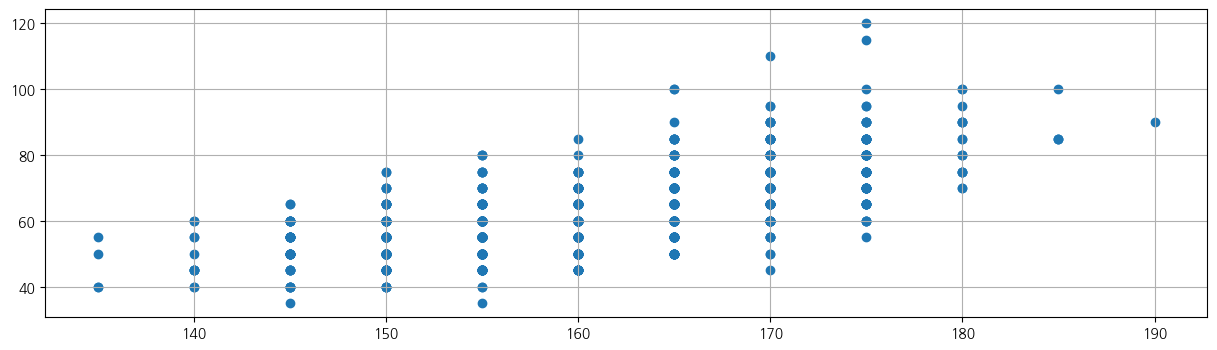

In [7]:
hei = data['height']
wei = data['weight']

plt.figure(figsize=(15,4))
plt.scatter(hei,wei)
plt.grid()

## 그룹 산점도

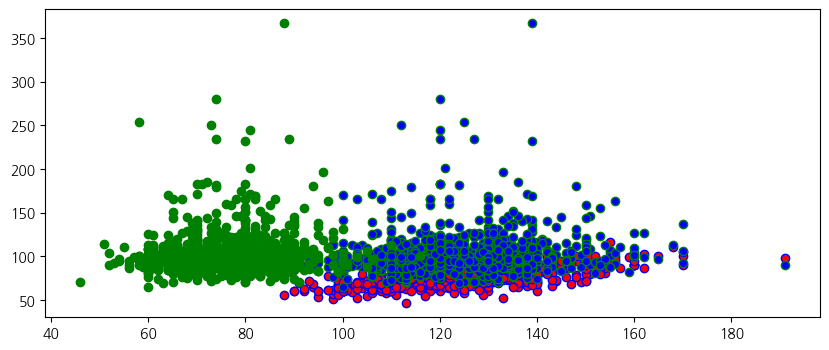

In [28]:
systolic = data['systolic']
dia = data['diastolic']
blood_s = data['blood_sugar']

plt.figure(figsize=(10,4))
plt.scatter(systolic, dia, color='r', edgecolors='b')
plt.scatter(systolic, blood_s, color='b', edgecolors='g')
plt.scatter(dia, blood_s, color='g')

## 히스토그램

In [14]:
female_h = data.loc[data['gender']==2, ['gender','height']]
female_h

,gender,height
1,2,150
2,2,155
4,2,155
8,2,150
9,2,150
...,...,...
990,2,150
992,2,150
993,2,145
997,2,155


(array([ 16.,  46., 134., 178., 105.,  33.,   6.]),
 array([135.        , 140.71428571, 146.42857143, 152.14285714,
        157.85714286, 163.57142857, 169.28571429, 175.        ]),
 <BarContainer object of 7 artists>)

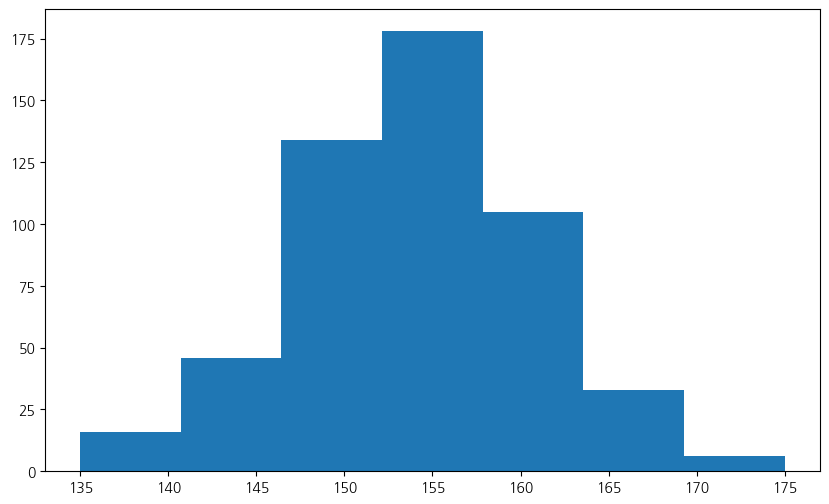

In [16]:
plt.figure(figsize=(10,6))
plt.hist(female_h['height'],7)

## 그룹 히스토그램

In [17]:
# 남자 및 여자 키 히스토그램
male_h = data.loc[data['gender']==1,['gender','height']]
male_h


,gender,height
0,1,165
3,1,160
5,1,185
6,1,165
7,1,160
...,...,...
991,1,160
994,1,160
995,1,165
996,1,165


(array([ 20.,  64., 150., 151.,  74.,  18.,   5.]),
 array([150.        , 155.71428571, 161.42857143, 167.14285714,
        172.85714286, 178.57142857, 184.28571429, 190.        ]),
 <BarContainer object of 7 artists>)

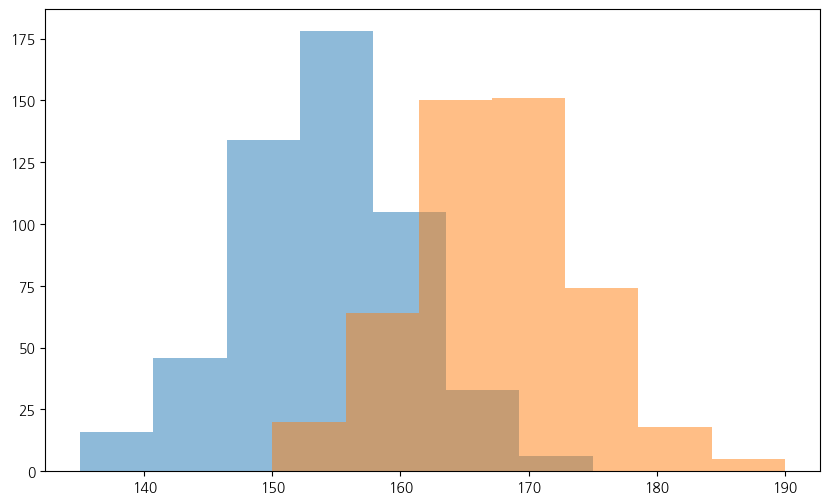

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(female_h['height'],7, alpha=0.5) #, alpha=0.5 투명도
plt.hist(male_h['height'],7, alpha=0.5)

## 그룹 누적 히스토그램
- 두 그룹의 데이터의 계급 합치기

In [23]:
import numpy as np
height = np.array([male_h['height'], female_h['height']], dtype=object)
height

array([0      165
       3      160
       5      185
       6      165
       7      160
             ...
       991    160
       994    160
       995    165
       996    165
       999    160
       Name: height, Length: 482, dtype: int64,
       1      150
       2      155
       4      155
       8      150
       9      150
             ...
       990    150
       992    150
       993    145
       997    155
       998    150
       Name: height, Length: 518, dtype: int64], dtype=object)

(array([[  0.,   4.,  80., 301.,  92.,   5.],
        [ 16., 184., 363., 338.,  94.,   5.]]),
 array([135.        , 144.16666667, 153.33333333, 162.5       ,
        171.66666667, 180.83333333, 190.        ]),
 <a list of 2 BarContainer objects>)

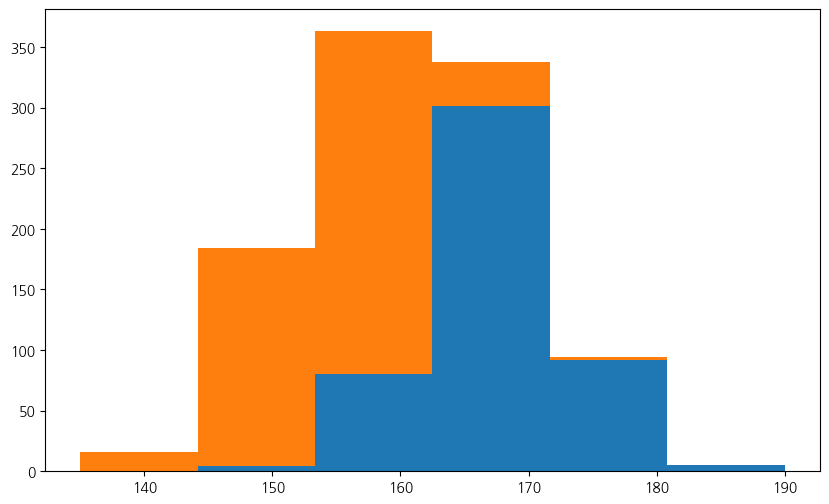

In [24]:
plt.figure(figsize=(10,6))
plt.hist(height,6,stacked=True)

## 상자수염 그래프

(130.0, 200.0)

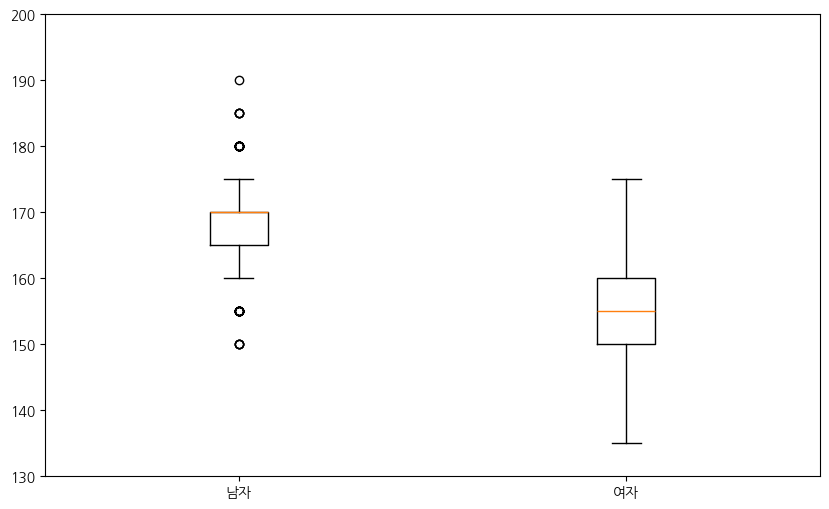

In [35]:
# 남자 키 여자 키 상자수염 그래프

plt.figure(figsize=(10,6))
height = np.array([male_h['height'],female_h['height']], dtype=object)

plt.boxplot(height, tick_labels=['남자','여자']) # 눈금 명도 바꿀 수 있다.
plt.ylim(130, 200)

(130.0, 200.0)

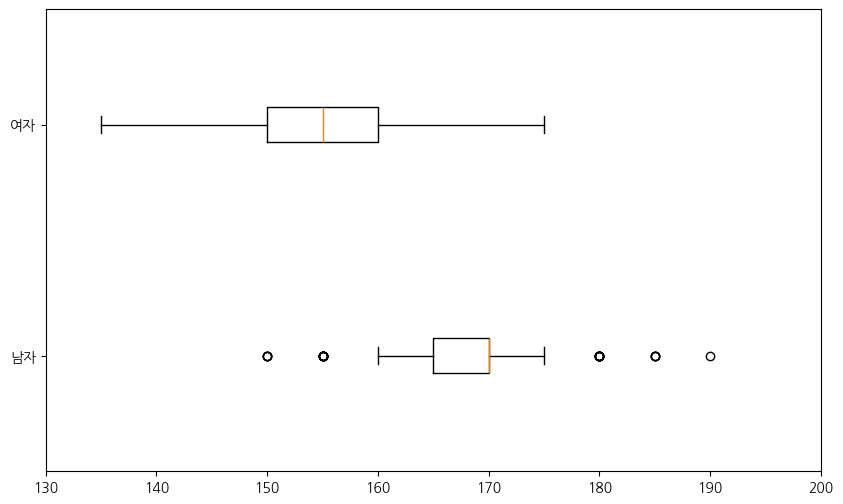

In [ ]:
# 가로 버전 가능
plt.figure(figsize=(10,6))
height = np.array([male_h['height'],female_h['height']], dtype=object)

plt.boxplot(height, tick_labels=['남자','여자'], vert=False) # vert --> 가로세로 버전 설정 가능
# plt.ylim(130, 200)

plt.xlim(130, 200)

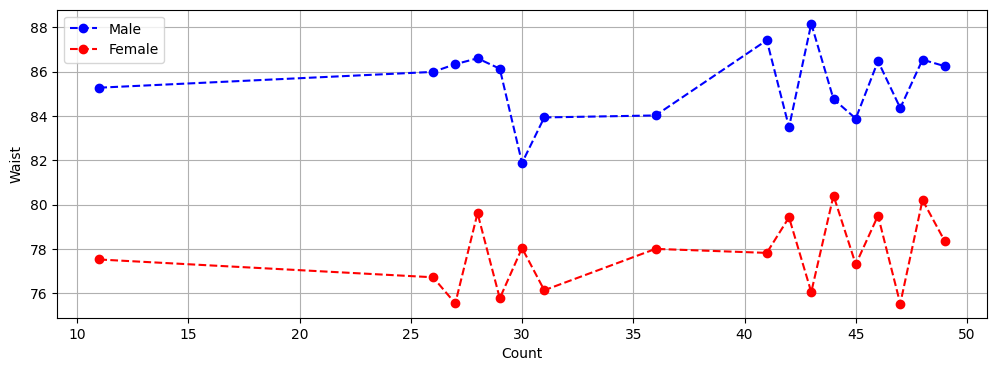

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 예제 풀이
# 4 번

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
data3 = data.loc[:,['city_code','gender','waist']]

male_data = data3[data3['gender']==1].groupby('city_code')['waist'].mean()
female_data = data3[data3['gender']==2].groupby('city_code')['waist'].mean()

plt.figure(figsize=(12,4))

plt.plot(male_data, color='b', marker='o', linestyle='--', label='Male')
plt.plot(female_data, color='r', marker='o', linestyle='--', label='Female')

plt.xlabel('Count')
plt.ylabel('Waist')
plt.grid()
plt.legend()


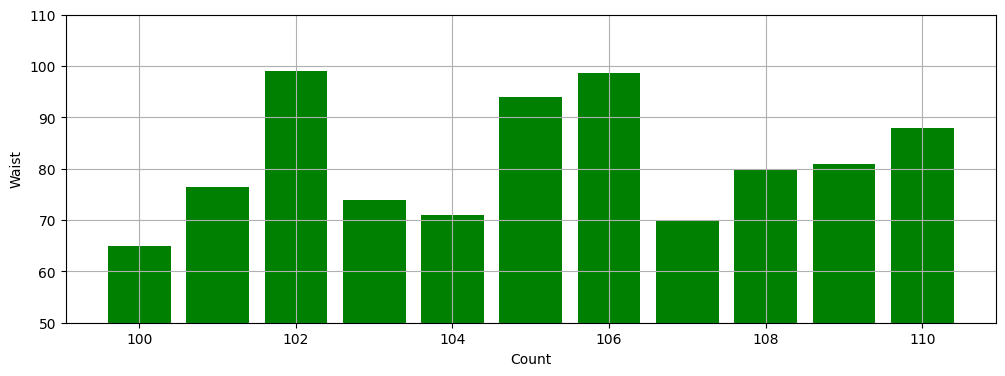

In [4]:
# 예제 풀이
# 5 번

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
data3 = data.loc[:,['city_code','gender','waist']]

waistData = data3.loc[100:110,['waist']]

plt.figure(figsize=(12,4))

plt.bar(waistData.index, waistData['waist'], color='g')

plt.ylim(50,110)
plt.xlabel('Count')
plt.ylabel('Waist')
plt.grid()
# plt.legend()


(0.0, 2.5)

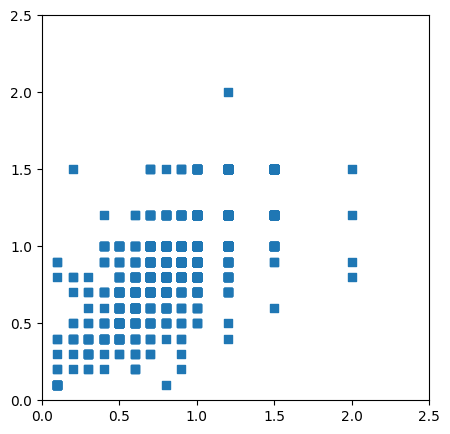

In [5]:
# 예제 풀이
# 6 번

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
data3 = data.loc[:,['city_code','gender','waist']]

leye = data['eye_left']
reye = data['eye_right']

plt.figure(figsize=(5,5))

plt.scatter(leye,reye, marker='s')


plt.xlim(0,2.5)
plt.ylim(0,2.5)

(array([  2.,  35., 136., 169., 111.,  47.,  12.,   6.]),
 array([ 53.,  60.,  67.,  74.,  81.,  88.,  95., 102., 109.]),
 <BarContainer object of 8 artists>)

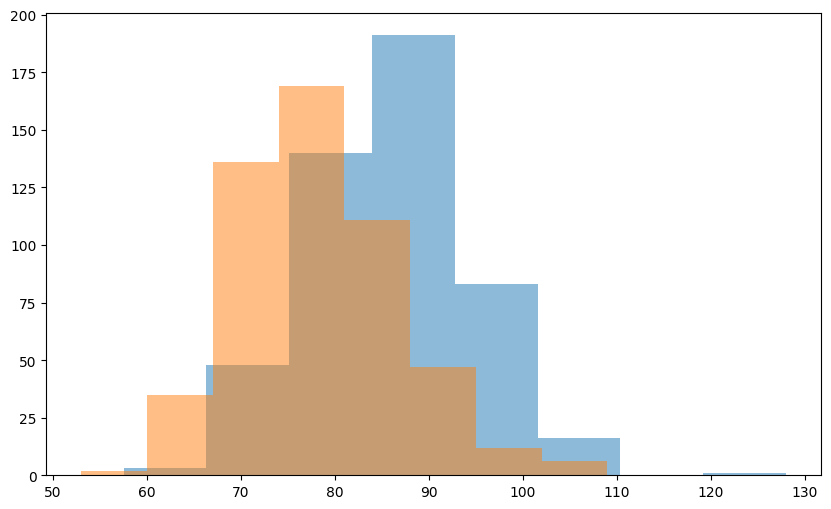

In [6]:
# 예제 풀이
# 7 번

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
data3 = data.loc[:,['city_code','gender','waist']]

male_data = data3.loc[data3['gender']==1, ['gender','waist']]
female_data = data3.loc[data3['gender']==2, ['gender','waist']]

plt.figure(figsize=(10,6))

plt.hist(male_data['waist'],8,alpha=0.5,label='Male')
plt.hist(female_data['waist'],8,alpha=0.5,label='Female')



In [7]:
# 예제 풀이
# 9 번

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
data6 = data.loc[:,['gender','height','weight','waist','drinking','smoking']]

# data6.loc[data6['gender']==1,data6['gender']] = 'Male'
# data6.loc[data6['gender']==2,data6['gender']] = 'Female'
# data6.loc[(data6['smoking']==1)|(data6['smoking']==2),data6['smoking']] = 'Non-smoking'
# data6.loc[(data6['smoking']==3),data6['smoking']] = 'Smoking'

# smoking = data6.groupby(['gender','Smoking'])['Smoking'].count()
# smoking = smoking.to_frame(name='count')
# smoking = smoking.reset_index()

# plt.figure(figsize=(10,6))

# plt.bar(smoking.index,smoking)


In [8]:
data6

,gender,height,weight,waist,drinking,smoking
0,1,165,60,72.1,0,1
1,2,150,65,81.0,0,1
2,2,155,55,70.0,0,1
3,1,160,70,90.8,0,1
4,2,155,50,75.2,0,1
...,...,...,...,...,...,...
995,1,165,70,92.0,1,3
996,1,165,70,88.0,0,2
997,2,155,55,80.2,1,1
998,2,150,55,79.5,0,1


<Axes: xlabel='smoking', ylabel='count'>

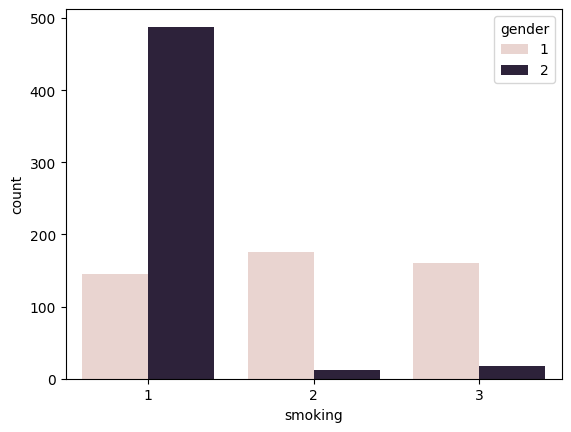

In [11]:
tmp = data6[['gender','smoking']]
sns.countplot(tmp, x='smoking', hue='gender')